# Hand Gesture Classification using CNN

This project explores the use of Convolutional Neural Networks (CNNs) for classifying hand gestures.

The dataset was created manually and consists of three gesture classes:

- Thumbs Up
- Peace Sign
- Open Palm

The goal is to understand the machine learning workflow, experiment with different settings, and observe how these changes affect model performance.

# 1. Importing Libraries

The required libraries are imported for image processing, visualization, dataset handling, and model training.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from PIL import Image

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 2. Connecting Google Drive

The dataset is stored in Google Drive and is loaded into Colab using the drive mount feature.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 3. Dataset Verification

Before training the model, the dataset structure and sample images are checked to ensure that the images are loaded correctly.

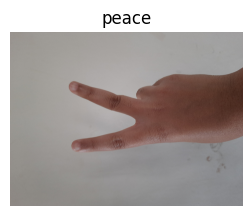

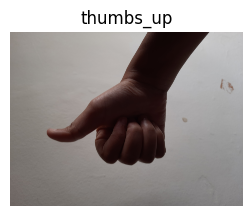

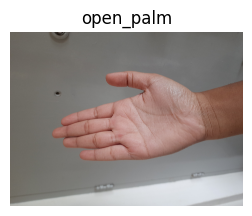

In [3]:
import matplotlib.pyplot as plt
import os
from PIL import Image

dataset_path = "/content/drive/MyDrive/CEAM/dataset"

classes = os.listdir(dataset_path)

for class_name in classes:
    class_folder = os.path.join(dataset_path, class_name)

    image_name = os.listdir(class_folder)[0]

    image_path = os.path.join(class_folder, image_name)

    img = Image.open(image_path)

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
    plt.show()

# 4. Dataset Statistics

The number of images in each class is counted to verify that the dataset is balanced.

In [4]:
import os

dataset_path = "/content/drive/MyDrive/CEAM/dataset"

for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)

    num_images = len(os.listdir(class_folder))

    print(f"{class_name}: {num_images} images")

peace: 30 images
thumbs_up: 30 images
open_palm: 30 images


# 5. Image Dimensions

The original dimensions of the images are checked before resizing.

All images were captured using the same camera and therefore have the same resolution.

In [5]:
from PIL import Image
import os

dataset_path = "/content/drive/MyDrive/CEAM/dataset"

for class_name in os.listdir(dataset_path):

    class_folder = os.path.join(dataset_path, class_name)

    image_name = os.listdir(class_folder)[0]

    image_path = os.path.join(class_folder, image_name)

    img = Image.open(image_path)

    print(class_name, img.size)

peace (4624, 3468)
thumbs_up (4624, 3468)
open_palm (4624, 3468)


In [6]:
import numpy as np
from PIL import Image
import os

dataset_path = "/content/drive/MyDrive/CEAM/dataset"

sample_class = os.listdir(dataset_path)[0]
sample_folder = os.path.join(dataset_path, sample_class)

sample_image = os.listdir(sample_folder)[0]

image_path = os.path.join(sample_folder, sample_image)

img = Image.open(image_path)

img_array = np.array(img)

print("Shape:", img_array.shape)
print("First pixel:", img_array[0,0])

Shape: (3468, 4624, 3)
First pixel: [159 154 151]


# 6. Data Preprocessing

The images are resized to 128 × 128 pixels and normalized.

A train-validation split of 80:20 is used.

In [7]:
dataset_path = "/content/drive/MyDrive/CEAM/dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [8]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

Found 72 images belonging to 3 classes.
Found 18 images belonging to 3 classes.


# 7. CNN Architecture

The CNN consists of two convolution layers followed by max pooling layers for feature extraction.

The extracted features are flattened and passed through a fully connected layer. A dropout layer is included to reduce overfitting.

The final output layer contains three neurons corresponding to the three gesture classes:
- Peace
- Thumbs Up
- Open Palm

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([

    # First Convolution Layer
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    # First Pooling Layer
    MaxPooling2D((2,2)),

    # Second Convolution Layer
    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    # Second Pooling Layer
    MaxPooling2D((2,2)),

    # Convert feature maps into a single vector
    Flatten(),

    # Fully Connected Layer
    Dense(
        128,
        activation='relu'
    ),

    # Dropout Layer
    Dropout(0.3),

    # Output Layer (3 gesture classes)
    Dense(
        3,
        activation='softmax'
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,707 (28.20 MB)

 Trainable params: 7,392,707 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

# Experiment 1: Baseline CNN Model

For the first experiment, I trained a simple CNN model on my hand gesture dataset.

Before trying any modifications or improvements, I wanted to establish a baseline result that I could compare future experiments against.

The dataset contains three classes:

- Peace Sign
- Thumbs Up
- Open Palm

The images were resized to 128 × 128 pixels and split into training and validation sets.

The model consists of two convolution layers, max pooling layers, a fully connected layer, and a dropout layer with a value of 0.3.

I used the Adam optimizer and trained the model for 15 epochs.

My expectation was that the model would learn the basic differences between the three gestures and provide a reference point for later experiments.

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 55s 11s/step - accuracy: 0.3472 - loss: 3.1816 - val_accuracy: 0.3333 - val_loss: 2.0632
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.3194 - loss: 1.5475 - val_accuracy: 0.2778 - val_loss: 1.1142
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.4861 - loss: 1.0409 - val_accuracy: 0.3333 - val_loss: 1.1383
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.4167 - loss: 0.9891 - val_accuracy: 0.3333 - val_loss: 1.0745
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.6528 - loss: 0.8607 - val_accuracy: 0.3333 - val_loss: 1.1335
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.7639 - loss: 0.6641 - val_accuracy: 0.3889 - val_loss: 1.1936
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.8333 - loss: 0.5263 - val_accuracy: 0.3889 - val_loss: 1.1036
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.9028 - loss: 0.3358 - val_accuracy: 0.3889 - val_loss: 1.1187
Epoch 9

# Experiment 1 Results

The training and validation performance are visualized below.

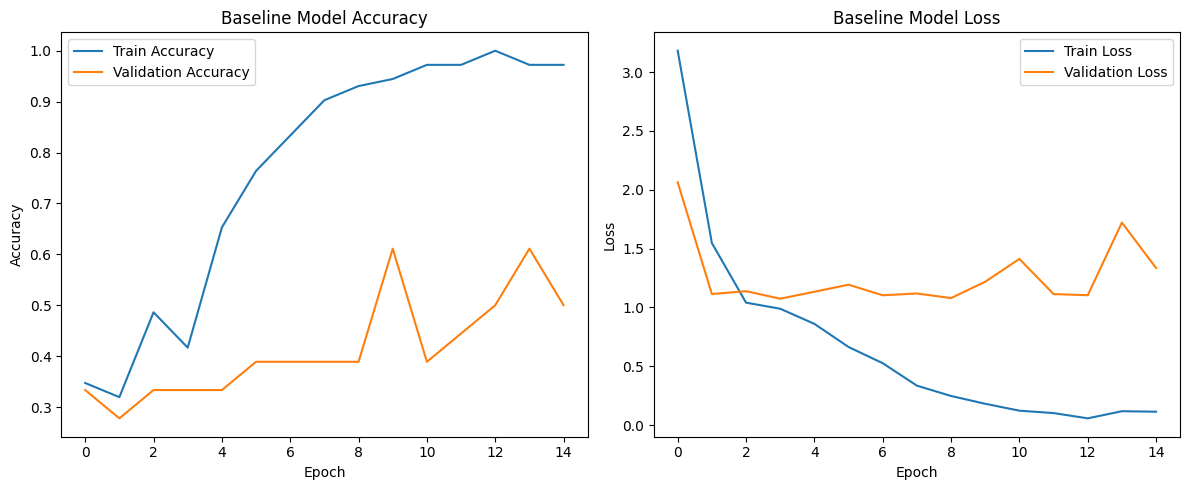

In [13]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Baseline Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Baseline Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
print("Best Training Accuracy:",
      max(history.history['accuracy']))

print("Best Validation Accuracy:",
      max(history.history['val_accuracy']))

Best Training Accuracy: 1.0
Best Validation Accuracy: 0.6111111044883728


# Observations

The model learned the training dataset very well and eventually reached very high training accuracy.

However, the validation accuracy remained much lower than the training accuracy.

This suggests that the model was able to memorize the training images but had difficulty performing well on unseen images.

The large difference between training and validation performance indicated that overfitting was occurring.

This experiment helped me understand why validation accuracy is important and why a model with very high training accuracy is not always a good model.

# Experiment 2: Data Augmentation

After observing the results of the baseline model, I noticed that the model was overfitting the training dataset.

One possible reason for this was the small dataset size. Although I had collected 90 images, this is still a relatively small dataset for training a CNN.

To address this, I decided to use data augmentation.

Data augmentation creates modified versions of existing images by applying small transformations such as rotations, shifts, zooming, and horizontal flipping.

The idea is to expose the model to more variations of the same gesture without collecting additional images.

I expected this to help the model learn the gesture patterns more effectively and reduce its tendency to memorize specific training images.

##Data Augmentation Generator

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

aug_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

##Recreate Train and Validation Data

In [16]:
train_data_aug = aug_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

val_data_aug = aug_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

Found 72 images belonging to 3 classes.
Found 18 images belonging to 3 classes.


##Model Code

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model_aug = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        3,
        activation='softmax'
    )

])

##Compile Model

In [18]:
model_aug.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

##Train Model

In [19]:
history_aug = model_aug.fit(
    train_data_aug,
    validation_data=val_data_aug,
    epochs=15
)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.2639 - loss: 3.6011 - val_accuracy: 0.3889 - val_loss: 1.1021
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.4583 - loss: 1.0845 - val_accuracy: 0.3333 - val_loss: 1.1057
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.3750 - loss: 1.1297 - val_accuracy: 0.3333 - val_loss: 1.0928
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.4583 - loss: 1.0351 - val_accuracy: 0.3889 - val_loss: 1.0848
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.5278 - loss: 1.0097 - val_accuracy: 0.3889 - val_loss: 1.0876
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.5278 - loss: 1.0154 - val_accuracy: 0.3889 - val_loss: 1.0915
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.4306 - loss: 1.0041 - val_accuracy: 0.3889 - val_loss: 1.0952
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.6111 - loss: 0.9371 - val_accuracy: 0.3889 - val_loss: 1.0697
Epoch 9/

##Plotting Results

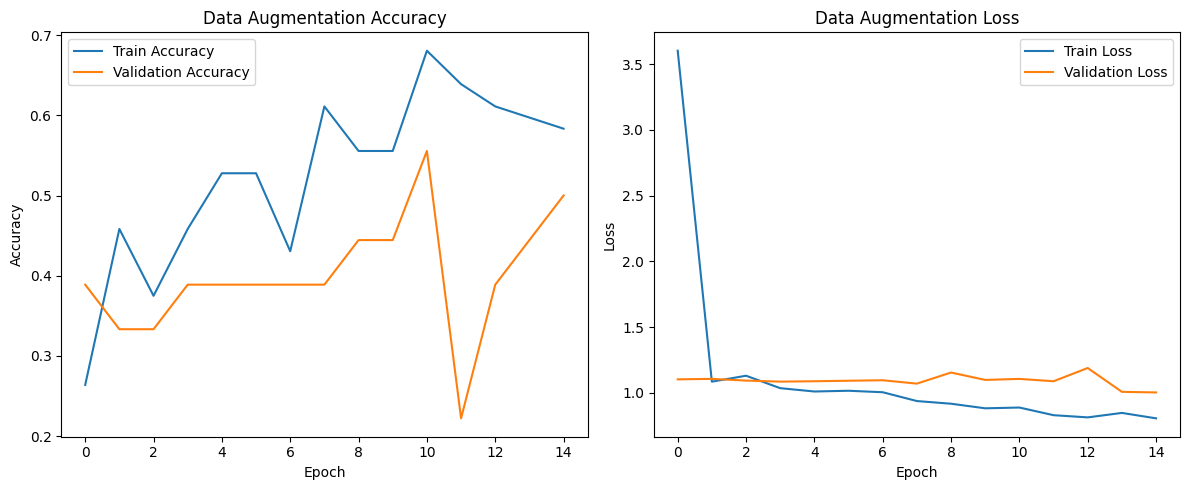

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_aug.history['accuracy'], label='Train Accuracy')
plt.plot(history_aug.history['val_accuracy'], label='Validation Accuracy')
plt.title('Data Augmentation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_aug.history['loss'], label='Train Loss')
plt.plot(history_aug.history['val_loss'], label='Validation Loss')
plt.title('Data Augmentation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

##Calculating Best Accuracy

In [21]:
print("Best Training Accuracy:",
      max(history_aug.history['accuracy']))

print("Best Validation Accuracy:",
      max(history_aug.history['val_accuracy']))

Best Training Accuracy: 0.6805555820465088
Best Validation Accuracy: 0.5555555820465088


# Observations

After applying data augmentation, I observed that the training accuracy decreased compared to the baseline model.

This was expected because the augmented images introduced additional variation, making the learning task more challenging.

The validation accuracy remained similar to the baseline model, although it did not improve as much as I initially expected.

Even though the accuracy improvement was limited, the experiment showed that data augmentation reduced the model's ability to simply memorize the training images.

This experiment helped me understand how data augmentation can be used to increase dataset diversity and improve the robustness of a model.

# Experiment 3: Increasing the Dropout Rate

In the baseline model, the training accuracy became very high while the validation accuracy remained much lower. This made me think that the model was learning the training images very well but was struggling with new images.

To test this, I increased the dropout rate from 0.3 to 0.5.

Dropout randomly switches off some neurons during training. Because of this, the model cannot depend too much on a few neurons and is forced to learn more general patterns.

I wanted to see whether increasing the dropout rate would reduce overfitting and help the model perform better on the validation dataset.

For this experiment, everything else was kept the same as the baseline model. The only change was increasing the dropout value.

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model_dropout = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    # Changed from 0.3 to 0.5
    Dropout(0.5),

    Dense(
        3,
        activation='softmax'
    )

])

In [23]:
model_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history_dropout = model_dropout.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 5s/step - accuracy: 0.2361 - loss: 5.5618 - val_accuracy: 0.3333 - val_loss: 2.0104
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.4167 - loss: 1.2447 - val_accuracy: 0.2222 - val_loss: 1.0941
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.5278 - loss: 1.0488 - val_accuracy: 0.4444 - val_loss: 1.0861
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.5556 - loss: 1.0139 - val_accuracy: 0.3889 - val_loss: 1.0817
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.7083 - loss: 0.9051 - val_accuracy: 0.4444 - val_loss: 1.0702
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.7222 - loss: 0.8085 - val_accuracy: 0.6667 - val_loss: 1.0540
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.7639 - loss: 0.6569 - val_accuracy: 0.4444 - val_loss: 1.0876
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.8333 - loss: 0.5082 - val_accuracy: 0.6111 - val_loss: 0.9797
Epoch 9/

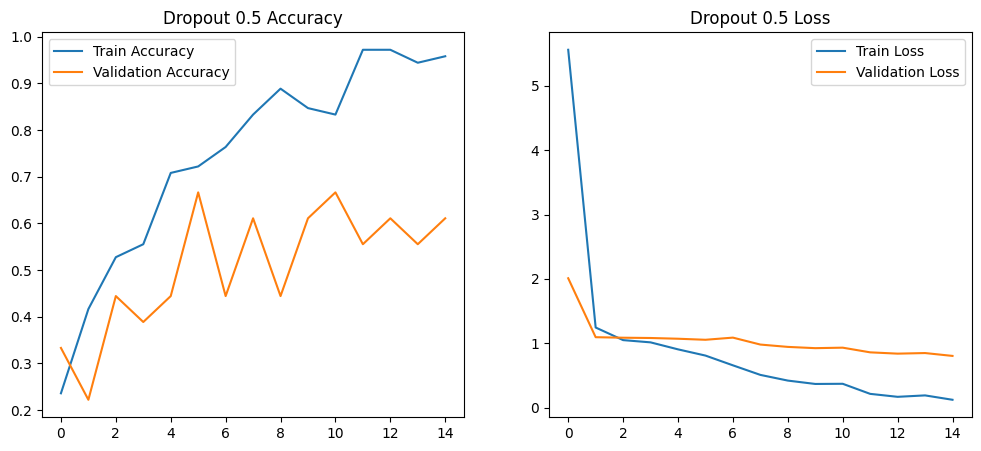

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dropout.history['accuracy'], label='Train Accuracy')
plt.plot(history_dropout.history['val_accuracy'], label='Validation Accuracy')
plt.title('Dropout 0.5 Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_dropout.history['loss'], label='Train Loss')
plt.plot(history_dropout.history['val_loss'], label='Validation Loss')
plt.title('Dropout 0.5 Loss')
plt.legend()

plt.show()

In [27]:
print("Best Training Accuracy:",
      max(history_dropout.history['accuracy']))

print("Best Validation Accuracy:",
      max(history_dropout.history['val_accuracy']))

Best Training Accuracy: 0.9722222089767456
Best Validation Accuracy: 0.6666666865348816


# Observations

In this experiment, I increased the dropout rate from 0.3 to 0.5.

Compared to the baseline model, the validation accuracy improved from 61.1% to 66.7%, which was the highest validation accuracy obtained among all experiments.

The training accuracy remained high, but the gap between training and validation performance was slightly reduced.

This suggests that increasing the dropout rate helped reduce overfitting by preventing the model from relying too heavily on specific neurons.

Among all the experiments performed, this configuration produced the best validation performance on the dataset.

# Experiment 4: Changing the Learning Rate(Failed Experiment)

For this experiment, I wanted to understand how the learning rate affects the training process.

The learning rate controls how much the model changes its weights after each update. A smaller learning rate takes smaller steps, while a larger learning rate takes bigger steps.

In the baseline model, the default learning rate of Adam was used. In this experiment, I increased the learning rate to 0.01.

My expectation was that the model would learn faster, but there was also a possibility that training could become unstable because the weight updates would be larger.

All other settings were kept the same as the baseline model so that I could clearly observe the effect of changing only the learning rate.

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model_lr = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        3,
        activation='softmax'
    )

])

In [29]:
from tensorflow.keras.optimizers import Adam

model_lr.compile(
    optimizer=Adam(learning_rate=0.01), # Higher Learnning Rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
history_lr = model_lr.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.2917 - loss: 14.1060 - val_accuracy: 0.2778 - val_loss: 1.1172
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.2917 - loss: 1.1124 - val_accuracy: 0.3333 - val_loss: 1.0990
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.3333 - loss: 1.0980 - val_accuracy: 0.3333 - val_loss: 1.0994
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.3194 - loss: 1.0983 - val_accuracy: 0.3333 - val_loss: 1.0991
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.3333 - loss: 1.1008 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.3611 - loss: 1.0977 - val_accuracy: 0.3333 - val_loss: 1.0987
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.3472 - loss: 1.0991 - val_accuracy: 0.3333 - val_loss: 1.0988
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.3056 - loss: 1.1004 - val_accuracy: 0.3333 - val_loss: 1.0988
Epoch 9

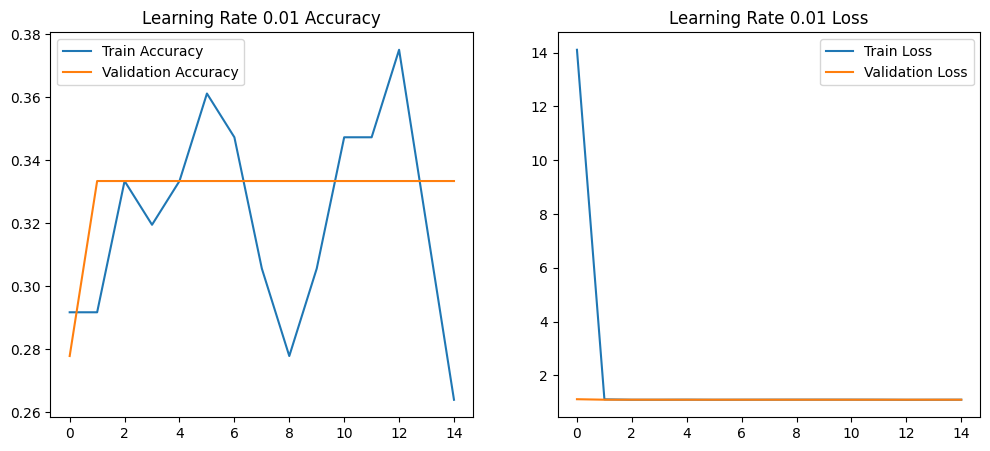

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_lr.history['accuracy'], label='Train Accuracy')
plt.plot(history_lr.history['val_accuracy'], label='Validation Accuracy')
plt.title('Learning Rate 0.01 Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_lr.history['loss'], label='Train Loss')
plt.plot(history_lr.history['val_loss'], label='Validation Loss')
plt.title('Learning Rate 0.01 Loss')
plt.legend()

plt.show()

In [32]:
print("Best Training Accuracy:",
      max(history_lr.history['accuracy']))

print("Best Validation Accuracy:",
      max(history_lr.history['val_accuracy']))

Best Training Accuracy: 0.375
Best Validation Accuracy: 0.3333333432674408


# Observations

After training the model with a higher learning rate, I compared the results with the baseline model.

I observed the changes in training accuracy, validation accuracy, and loss values across th# Observations

For this experiment, I increased the learning rate from 0.001 to 0.01.

The model failed to learn meaningful patterns from the dataset and both training and validation accuracy remained close to 33%, which is approximately the accuracy expected from random guessing among three classes.

The loss values also showed very little improvement throughout training.

I believe this happened because the learning rate was too large, causing the weight updates to become too aggressive. Instead of gradually moving toward a better solution, the model repeatedly overshot good parameter values and was unable to converge properly.

This experiment demonstrated the importance of choosing an appropriate learning rate when training neural networks.e epochs.

A larger learning rate causes the weights to change more aggressively. If the updates become too large, the model may miss better solutions and training can become unstable.

This experiment helped me understand the importance of choosing an appropriate learning rate when training a neural network.

# Final Comparison of Experiments

The table below summarizes the performance of all experiments conducted during this project.

In [34]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Experiment": [
        "Baseline CNN",
        "Data Augmentation",
        "Dropout 0.5",
        "Learning Rate 0.01"
    ],

    "Best Training Accuracy (%)": [
        max(history.history['accuracy']) * 100,
        max(history_aug.history['accuracy']) * 100,
        max(history_dropout.history['accuracy']) * 100,
        max(history_lr.history['accuracy']) * 100
    ],

    "Best Validation Accuracy (%)": [
        max(history.history['val_accuracy']) * 100,
        max(history_aug.history['val_accuracy']) * 100,
        max(history_dropout.history['val_accuracy']) * 100,
        max(history_lr.history['val_accuracy']) * 100
    ]
})

comparison_df.round(2)

,Experiment,Best Training Accuracy (%),Best Validation Accuracy (%)
0,Baseline CNN,100.00,61.11
1,Data Augmentation,68.06,55.56
2,Dropout 0.5,97.22,66.67
3,Learning Rate 0.01,37.50,33.33
